In [1]:
# Cell 1 - Mount Google Drive và nhập trực tiếp đường dẫn
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

ASL_ROOT = Path("/content/drive/MyDrive/data/ASL/ASL")
VSL_ROOT = Path("/content/drive/MyDrive/data/VSL/VSL")
OUTPUT_DIR = Path("/content/DBML/outputs/classification_difficulty_4_8")

# Không kiểm tra cứng đường dẫn đầu vào; thư mục output sẽ được tạo nếu chưa có.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ASL_ROOT:", ASL_ROOT)
print("VSL_ROOT:", VSL_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ASL_ROOT: /content/drive/MyDrive/data/ASL/ASL
VSL_ROOT: /content/drive/MyDrive/data/VSL/VSL
OUTPUT_DIR: /content/DBML/outputs/classification_difficulty_4_8


In [2]:
# Cell 2 - Import thư viện
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)
print("Import thư viện thành công.")

Import thư viện thành công.


In [3]:
# Cell 3 - Kiểm tra cấu trúc dữ liệu
def inspect_dataset_root(dataset_name, dataset_root):
    dataset_root = Path(dataset_root)
    if not dataset_root.exists():
        raise FileNotFoundError(f"[{dataset_name}] Không tìm thấy thư mục: {dataset_root}")
    if not dataset_root.is_dir():
        raise NotADirectoryError(f"[{dataset_name}] Đường dẫn không phải thư mục: {dataset_root}")

    # Chỉ thư mục con trực tiếp mới được xem là class.
    class_dirs = sorted(
        [path for path in dataset_root.iterdir() if path.is_dir()],
        key=lambda path: path.name.casefold(),
    )
    npz_files = sorted(
        [npz_path for class_dir in class_dirs for npz_path in class_dir.glob("*.npz")],
        key=lambda path: str(path).casefold(),
    )

    print("=" * 80)
    print("dataset_name:", dataset_name)
    print("dataset_root:", dataset_root)
    print("Số lượng thư mục class:", len(class_dirs))
    print("10 class đầu tiên:", [path.name for path in class_dirs[:10]])
    print("Tổng số file .npz:", len(npz_files))
    print("5 file .npz mẫu:")
    for sample_path in npz_files[:5]:
        print("  -", sample_path)

    if not class_dirs:
        print(f"CẢNH BÁO: [{dataset_name}] không có thư mục class nào.")
    if not npz_files:
        print(f"CẢNH BÁO: [{dataset_name}] không có file .npz nào ở tầng class trực tiếp.")

inspect_dataset_root("ASL", ASL_ROOT)
inspect_dataset_root("VSL", VSL_ROOT)

dataset_name: ASL
dataset_root: /content/drive/MyDrive/data/ASL/ASL
Số lượng thư mục class: 2000
10 class đầu tiên: ['a', 'a lot', 'abdomen', 'able', 'about', 'above', 'accent', 'accept', 'accident', 'accomplish']
Tổng số file .npz: 11980
5 file .npz mẫu:
  - /content/drive/MyDrive/data/ASL/ASL/a lot/02124.npz
  - /content/drive/MyDrive/data/ASL/ASL/a lot/02125.npz
  - /content/drive/MyDrive/data/ASL/ASL/a lot/02126.npz
  - /content/drive/MyDrive/data/ASL/ASL/a lot/02128.npz
  - /content/drive/MyDrive/data/ASL/ASL/a lot/02129.npz
dataset_name: VSL
dataset_root: /content/drive/MyDrive/data/VSL/VSL
Số lượng thư mục class: 3314
10 class đầu tiên: ['0 (số không)', '1', '1 000 000 (một triệu)', '1 000 000 000 (một tỉ)', '10', '10 000 (mười nghìn)', '100', '1000 (một nghìn)', '11', '12']
Tổng số file .npz: 4362
5 file .npz mẫu:
  - /content/drive/MyDrive/data/VSL/VSL/0 (số không)/D0529.npz
  - /content/drive/MyDrive/data/VSL/VSL/1 000 000 (một triệu)/D0551B.npz
  - /c

In [4]:
# Cell 4 - Hàm đọc file .npz
PREFERRED_NPZ_KEYS = (
    "keypoints", "data", "arr_0", "x",
    "features", "landmarks",
)

def load_npz_keypoints(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path, allow_pickle=False) as npz_file:
        selected_key = None
        selected_array = None

        # Ưu tiên các tên keypoint phổ biến, nhưng chỉ nhận array không rỗng có ít nhất 2 chiều.
        for key in PREFERRED_NPZ_KEYS:
            if key in npz_file.files:
                candidate = np.asarray(npz_file[key])
                if candidate.ndim >= 2 and candidate.size > 0:
                    selected_key = key
                    selected_array = candidate
                    break

        # Nếu không có key ưu tiên phù hợp, lấy array đầu tiên có ít nhất 2 chiều.
        if selected_array is None:
            for key in npz_file.files:
                candidate = np.asarray(npz_file[key])
                if candidate.ndim >= 2 and candidate.size > 0:
                    selected_key = key
                    selected_array = candidate
                    break

        if selected_array is None:
            raise ValueError(
                f"Không tìm thấy array keypoint không rỗng có ndim >= 2. "
                f"Các key hiện có: {npz_file.files}"
            )

        original_shape = tuple(int(value) for value in selected_array.shape)
        if selected_array.shape[0] == 0:
            raise ValueError(f"Array '{selected_key}' có sequence rỗng: {original_shape}")

        try:
            keypoints_2d = np.asarray(selected_array, dtype=np.float32)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"Array '{selected_key}' không phải dữ liệu số: {exc}") from exc

        if keypoints_2d.ndim > 2:
            keypoints_2d = keypoints_2d.reshape(keypoints_2d.shape[0], -1)
        if keypoints_2d.ndim != 2 or keypoints_2d.shape[1] == 0:
            raise ValueError(
                f"Array '{selected_key}' không thể chuyển thành shape (T, D) hợp lệ: {original_shape}"
            )

        keypoints_2d = np.nan_to_num(
            keypoints_2d, nan=0.0, posinf=0.0, neginf=0.0
        )
        return keypoints_2d, selected_key, original_shape

In [5]:
# Cell 5 - Hàm tạo embedding thống kê
def make_statistical_embedding(keypoints):
    keypoints = np.asarray(keypoints, dtype=np.float32)
    if keypoints.ndim != 2 or keypoints.size == 0:
        raise ValueError(f"Keypoints phải có shape (T, D) không rỗng, nhận được {keypoints.shape}")

    sequence_length, feature_dim = keypoints.shape
    mean_vector = np.mean(keypoints, axis=0)
    std_vector = np.std(keypoints, axis=0)
    embedding = np.concatenate([mean_vector, std_vector]).astype(np.float32)
    embedding = np.nan_to_num(embedding, nan=0.0, posinf=0.0, neginf=0.0)

    if embedding.ndim != 1 or embedding.size == 0:
        raise ValueError(f"Embedding không hợp lệ: shape={embedding.shape}")

    return (
        embedding,
        int(sequence_length),
        int(feature_dim),
        int(embedding.size),
    )

In [6]:
# Cell 6 - Hàm load toàn bộ dataset
METADATA_COLUMNS = [
    "dataset", "class_name", "file_path", "sequence_length",
    "feature_dim", "embedding_dim", "selected_npz_key", "original_shape",
]
ERROR_COLUMNS = ["dataset", "file_path", "error_message"]

def load_dataset_embeddings(dataset_name, dataset_root):
    dataset_root = Path(dataset_root)
    if not dataset_root.exists():
        raise FileNotFoundError(f"[{dataset_name}] Không tìm thấy thư mục: {dataset_root}")

    class_dirs = sorted(
        [path for path in dataset_root.iterdir() if path.is_dir()],
        key=lambda path: path.name.casefold(),
    )
    npz_paths = sorted(
        [npz_path for class_dir in class_dirs for npz_path in class_dir.glob("*.npz")],
        key=lambda path: str(path).casefold(),
    )
    if not npz_paths:
        raise ValueError(
            f"[{dataset_name}] Không tìm thấy file theo cấu trúc "
            f"{dataset_root}/<class_name>/*.npz"
        )

    loaded_records = []
    errors = []
    for npz_path in tqdm(npz_paths, desc=f"Đang load {dataset_name}", unit="file"):
        try:
            # Không phân tích chuỗi tên; tên folder cha trực tiếp chính là nhãn.
            class_name = npz_path.parent.name
            keypoints, selected_key, original_shape = load_npz_keypoints(npz_path)
            embedding, sequence_length, feature_dim, embedding_dim = (
                make_statistical_embedding(keypoints)
            )
            loaded_records.append({
                "embedding": embedding,
                "dataset": dataset_name,
                "class_name": class_name,
                "file_path": str(npz_path),
                "sequence_length": sequence_length,
                "feature_dim": feature_dim,
                "embedding_dim": embedding_dim,
                "selected_npz_key": selected_key,
                "original_shape": str(original_shape),
            })
        except Exception as exc:
            errors.append({
                "dataset": dataset_name,
                "file_path": str(npz_path),
                "error_message": f"{type(exc).__name__}: {exc}",
            })

    if not loaded_records:
        error_preview = errors[:3]
        raise RuntimeError(
            f"[{dataset_name}] Không đọc thành công file nào. Lỗi mẫu: {error_preview}"
        )

    # Một ma trận (N, E) cần E cố định. Giữ kích thước phổ biến nhất và ghi log các ngoại lệ.
    dim_counts = pd.Series(
        [record["embedding_dim"] for record in loaded_records], dtype="int64"
    ).value_counts()
    expected_embedding_dim = int(dim_counts.index[0])
    consistent_records = []
    for record in loaded_records:
        if record["embedding_dim"] == expected_embedding_dim:
            consistent_records.append(record)
        else:
            errors.append({
                "dataset": dataset_name,
                "file_path": record["file_path"],
                "error_message": (
                    f"Embedding dimension không nhất quán: "
                    f"{record['embedding_dim']} != {expected_embedding_dim}"
                ),
            })

    embeddings = np.vstack(
        [record["embedding"] for record in consistent_records]
    ).astype(np.float32)
    labels = [record["class_name"] for record in consistent_records]
    metadata_df = pd.DataFrame(
        [{column: record[column] for column in METADATA_COLUMNS} for record in consistent_records],
        columns=METADATA_COLUMNS,
    )
    error_df = pd.DataFrame(errors, columns=ERROR_COLUMNS)

    lengths = metadata_df["sequence_length"].to_numpy(dtype=float)
    print("\n" + "=" * 80)
    print(f"[{dataset_name}] Số sample đọc thành công: {len(metadata_df)}")
    print(f"[{dataset_name}] Số file lỗi/không nhất quán: {len(error_df)}")
    print(f"[{dataset_name}] Số class: {metadata_df['class_name'].nunique()}")
    print(f"[{dataset_name}] embedding_dim: {embeddings.shape[1]}")
    print(
        f"[{dataset_name}] sequence length mean/std/min/max: "
        f"{lengths.mean():.4f} / {lengths.std(ddof=0):.4f} / "
        f"{lengths.min():.0f} / {lengths.max():.0f}"
    )
    return embeddings, labels, metadata_df, error_df

In [7]:
# Cell 7 - Load ASL và VSL; hai dataset được xử lý độc lập
asl_embeddings, asl_labels, asl_meta, asl_errors = load_dataset_embeddings(
    "ASL", ASL_ROOT
)
vsl_embeddings, vsl_labels, vsl_meta, vsl_errors = load_dataset_embeddings(
    "VSL", VSL_ROOT
)

print("ASL embeddings shape:", asl_embeddings.shape)
print("VSL embeddings shape:", vsl_embeddings.shape)
if asl_embeddings.shape[1] != vsl_embeddings.shape[1]:
    print(
        "LƯU Ý: embedding_dim của ASL và VSL khác nhau. "
        "Notebook vẫn tính metric riêng cho từng dataset như yêu cầu."
    )

Đang load ASL:   0%|          | 0/11980 [00:00<?, ?file/s]


[ASL] Số sample đọc thành công: 11980
[ASL] Số file lỗi/không nhất quán: 0
[ASL] Số class: 2000
[ASL] embedding_dim: 660
[ASL] sequence length mean/std/min/max: 60.0000 / 0.0000 / 60 / 60


Đang load VSL:   0%|          | 0/4362 [00:00<?, ?file/s]


[VSL] Số sample đọc thành công: 4362
[VSL] Số file lỗi/không nhất quán: 0
[VSL] Số class: 3314
[VSL] embedding_dim: 660
[VSL] sequence length mean/std/min/max: 60.0000 / 0.0000 / 60 / 60
ASL embeddings shape: (11980, 660)
VSL embeddings shape: (4362, 660)


In [8]:
# Cell 8 - Tính class prototype
def compute_class_prototypes(embeddings, labels):
    embeddings = np.asarray(embeddings, dtype=np.float32)
    labels_array = np.asarray(labels, dtype=object)
    if embeddings.ndim != 2 or len(embeddings) != len(labels_array):
        raise ValueError("Embeddings phải có shape (N, E) và khớp số lượng labels.")

    class_names = sorted(set(labels), key=str.casefold)
    prototype_list = []
    class_counts = {}
    for class_name in class_names:
        class_mask = labels_array == class_name
        class_embeddings = embeddings[class_mask]
        class_counts[class_name] = int(class_embeddings.shape[0])
        prototype_list.append(np.mean(class_embeddings, axis=0))

    prototypes = np.vstack(prototype_list).astype(np.float32)
    prototypes = np.nan_to_num(prototypes, nan=0.0, posinf=0.0, neginf=0.0)
    return prototypes, class_names, class_counts

In [9]:
# Cell 9 - Tính inter-class similarity
def compute_inter_class_similarity(prototypes, class_names, threshold=0.85):
    prototypes = np.asarray(prototypes, dtype=np.float32)
    if prototypes.ndim != 2 or len(class_names) != len(prototypes):
        raise ValueError("Prototypes và class_names không khớp.")

    similarity_matrix = cosine_similarity(prototypes)
    upper_rows, upper_cols = np.triu_indices(len(class_names), k=1)
    pair_values = similarity_matrix[upper_rows, upper_cols]
    class_array = np.asarray(class_names, dtype=object)
    pair_df = pd.DataFrame({
        "class_a": class_array[upper_rows],
        "class_b": class_array[upper_cols],
        "cosine_similarity": pair_values,
    }).sort_values("cosine_similarity", ascending=False, ignore_index=True)

    if pair_values.size == 0:
        mean_similarity = float("nan")
        max_similarity = float("nan")
        similar_pair_count = 0
    else:
        mean_similarity = float(np.mean(pair_values))
        max_similarity = float(np.max(pair_values))
        similar_pair_count = int(np.sum(pair_values >= threshold))

    metrics = {
        "mean_inter_class_similarity": mean_similarity,
        "max_inter_class_similarity": max_similarity,
        "number_of_similar_class_pairs_threshold_0_85": similar_pair_count,
    }
    return metrics, pair_df, similarity_matrix

In [10]:
# Cell 10 - Tính intra-class variability
def compute_intra_class_variability(embeddings, labels, prototypes, class_names):
    embeddings = np.asarray(embeddings, dtype=np.float32)
    prototypes = np.asarray(prototypes, dtype=np.float32)
    labels_array = np.asarray(labels, dtype=object)
    if embeddings.ndim != 2 or prototypes.ndim != 2:
        raise ValueError("Embeddings và prototypes phải là ma trận 2D.")

    rows = []
    for class_index, class_name in enumerate(class_names):
        class_mask = labels_array == class_name
        class_embeddings = embeddings[class_mask]
        if class_embeddings.shape[0] == 0:
            continue

        # Mỗi giá trị là 1 - cosine_similarity(sample, prototype của chính class đó).
        similarities = cosine_similarity(
            class_embeddings, prototypes[class_index].reshape(1, -1)
        ).ravel()
        cosine_distances = 1.0 - similarities
        rows.append({
            "class_name": class_name,
            "num_samples": int(class_embeddings.shape[0]),
            "mean_intra_class_variance": float(np.mean(cosine_distances)),
            "std_intra_class_variance": float(np.std(cosine_distances, ddof=0)),
        })

    intra_class_df = pd.DataFrame(rows).sort_values(
        "mean_intra_class_variance", ascending=False, ignore_index=True
    )
    # Dùng trung bình theo class (macro average) để class nhiều sample không lấn át class ít sample.
    class_means = intra_class_df["mean_intra_class_variance"].to_numpy(dtype=float)
    metrics = {
        "mean_intra_class_variance": float(np.mean(class_means)),
        "max_intra_class_variance": float(np.max(class_means)),
    }
    return metrics, intra_class_df

In [11]:
# Cell 11 - Tính sequence length metrics
def compute_sequence_length_metrics(metadata_df):
    if metadata_df.empty:
        raise ValueError("metadata_df rỗng, không thể tính sequence length metrics.")
    sequence_lengths = metadata_df["sequence_length"].to_numpy(dtype=float)
    return {
        "mean_sequence_length": float(np.mean(sequence_lengths)),
        "std_sequence_length": float(np.std(sequence_lengths, ddof=0)),
        "sequence_length_variance": float(np.var(sequence_lengths, ddof=0)),
        "min_sequence_length": float(np.min(sequence_lengths)),
        "max_sequence_length": float(np.max(sequence_lengths)),
    }

In [12]:
# Cell 12 - Tính toàn bộ metric riêng cho ASL và VSL
asl_prototypes, asl_class_names, asl_class_counts = compute_class_prototypes(
    asl_embeddings, asl_labels
)
vsl_prototypes, vsl_class_names, vsl_class_counts = compute_class_prototypes(
    vsl_embeddings, vsl_labels
)

asl_inter_metrics, asl_pair_df, asl_similarity_matrix = compute_inter_class_similarity(
    asl_prototypes, asl_class_names
)
vsl_inter_metrics, vsl_pair_df, vsl_similarity_matrix = compute_inter_class_similarity(
    vsl_prototypes, vsl_class_names
)

asl_intra_metrics, asl_intra_df = compute_intra_class_variability(
    asl_embeddings, asl_labels, asl_prototypes, asl_class_names
)
vsl_intra_metrics, vsl_intra_df = compute_intra_class_variability(
    vsl_embeddings, vsl_labels, vsl_prototypes, vsl_class_names
)

asl_sequence_metrics = compute_sequence_length_metrics(asl_meta)
vsl_sequence_metrics = compute_sequence_length_metrics(vsl_meta)

print("ASL inter-class metrics:", json.dumps(asl_inter_metrics, indent=2, ensure_ascii=False))
print("VSL inter-class metrics:", json.dumps(vsl_inter_metrics, indent=2, ensure_ascii=False))
print("ASL intra-class metrics:", json.dumps(asl_intra_metrics, indent=2, ensure_ascii=False))
print("VSL intra-class metrics:", json.dumps(vsl_intra_metrics, indent=2, ensure_ascii=False))
print("ASL sequence metrics:", json.dumps(asl_sequence_metrics, indent=2, ensure_ascii=False))
print("VSL sequence metrics:", json.dumps(vsl_sequence_metrics, indent=2, ensure_ascii=False))

ASL inter-class metrics: {
  "mean_inter_class_similarity": 0.9871969819068909,
  "max_inter_class_similarity": 0.9999179244041443,
  "number_of_similar_class_pairs_threshold_0_85": 1999000
}
VSL inter-class metrics: {
  "mean_inter_class_similarity": 0.987494707107544,
  "max_inter_class_similarity": 0.9999886155128479,
  "number_of_similar_class_pairs_threshold_0_85": 5489641
}
ASL intra-class metrics: {
  "mean_intra_class_variance": 0.013719045575940982,
  "max_intra_class_variance": 0.03317733854055405
}
VSL intra-class metrics: {
  "mean_intra_class_variance": 0.00022455432853648848,
  "max_intra_class_variance": 0.007679164409637451
}
ASL sequence metrics: {
  "mean_sequence_length": 60.0,
  "std_sequence_length": 0.0,
  "sequence_length_variance": 0.0,
  "min_sequence_length": 60.0,
  "max_sequence_length": 60.0
}
VSL sequence metrics: {
  "mean_sequence_length": 60.0,
  "std_sequence_length": 0.0,
  "sequence_length_variance": 0.0,
  "min_sequence_length": 60.0,
  "max_sequenc

In [13]:
# Cell 13 - Tạo bảng summary
INTERPRETATIONS = {
    "mean_inter_class_similarity": "Higher value means class prototypes are closer, increasing confusion risk.",
    "max_inter_class_similarity": "Higher value indicates the most similar class pair is harder to separate.",
    "number_of_similar_class_pairs_threshold_0_85": "More pairs above threshold means more potentially confusing class pairs.",
    "mean_intra_class_variance": "Higher value means samples within the same class vary more.",
    "max_intra_class_variance": "Higher value indicates at least one highly unstable class.",
    "sequence_length_variance": "Higher value means sign duration varies more.",
    "std_sequence_length": "Higher value means sequence length is less stable.",
}

asl_all_metrics = {**asl_inter_metrics, **asl_intra_metrics, **asl_sequence_metrics}
vsl_all_metrics = {**vsl_inter_metrics, **vsl_intra_metrics, **vsl_sequence_metrics}

def compare_difficulty(asl_value, vsl_value):
    if pd.isna(asl_value) or pd.isna(vsl_value):
        return "Unavailable"
    if asl_value > vsl_value:
        return "ASL"
    if vsl_value > asl_value:
        return "VSL"
    return "Tie"

summary_rows = []
for metric_name, interpretation in INTERPRETATIONS.items():
    asl_value = asl_all_metrics[metric_name]
    vsl_value = vsl_all_metrics[metric_name]
    summary_rows.append({
        "Metric": metric_name,
        "ASL": asl_value,
        "VSL": vsl_value,
        "More_Difficult": compare_difficulty(asl_value, vsl_value),
        "Interpretation": interpretation,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Metric,ASL,VSL,More_Difficult,Interpretation
0,mean_inter_class_similarity,9.871970e-01,9.874947e-01,VSL,"Higher value means class prototypes are closer, increasing confusion risk."
1,max_inter_class_similarity,9.999179e-01,9.999886e-01,VSL,Higher value indicates the most similar class pair is harder to separate.
2,number_of_similar_class_pairs_threshold_0_85,1.999000e+06,5.489641e+06,VSL,More pairs above threshold means more potentially confusing class pairs.
3,mean_intra_class_variance,1.371905e-02,2.245543e-04,ASL,Higher value means samples within the same class vary more.
4,max_intra_class_variance,3.317734e-02,7.679164e-03,ASL,Higher value indicates at least one highly unstable class.
5,sequence_length_variance,0.000000e+00,0.000000e+00,Tie,Higher value means sign duration varies more.
6,std_sequence_length,0.000000e+00,0.000000e+00,Tie,Higher value means sequence length is less stable.


In [14]:
# Cell 14 - Lưu output CSV
combined_metadata_df = pd.concat([asl_meta, vsl_meta], ignore_index=True)
combined_error_df = pd.concat([asl_errors, vsl_errors], ignore_index=True)

output_paths = {
    "classification_difficulty_summary.csv": OUTPUT_DIR / "classification_difficulty_summary.csv",
    "similar_class_pairs_asl.csv": OUTPUT_DIR / "similar_class_pairs_asl.csv",
    "similar_class_pairs_vsl.csv": OUTPUT_DIR / "similar_class_pairs_vsl.csv",
    "intra_class_variance_asl.csv": OUTPUT_DIR / "intra_class_variance_asl.csv",
    "intra_class_variance_vsl.csv": OUTPUT_DIR / "intra_class_variance_vsl.csv",
    "sample_embeddings_metadata.csv": OUTPUT_DIR / "sample_embeddings_metadata.csv",
    "error_log.csv": OUTPUT_DIR / "error_log.csv",
}

summary_df.to_csv(output_paths["classification_difficulty_summary.csv"], index=False, encoding="utf-8-sig")
asl_pair_df.to_csv(output_paths["similar_class_pairs_asl.csv"], index=False, encoding="utf-8-sig")
vsl_pair_df.to_csv(output_paths["similar_class_pairs_vsl.csv"], index=False, encoding="utf-8-sig")
asl_intra_df.to_csv(output_paths["intra_class_variance_asl.csv"], index=False, encoding="utf-8-sig")
vsl_intra_df.to_csv(output_paths["intra_class_variance_vsl.csv"], index=False, encoding="utf-8-sig")
combined_metadata_df.to_csv(output_paths["sample_embeddings_metadata.csv"], index=False, encoding="utf-8-sig")
combined_error_df.to_csv(output_paths["error_log.csv"], index=False, encoding="utf-8-sig")

print("Đã lưu các file CSV:")
for name, path in output_paths.items():
    print(f"  - {name}: {path}")

Đã lưu các file CSV:
  - classification_difficulty_summary.csv: /content/DBML/outputs/classification_difficulty_4_8/classification_difficulty_summary.csv
  - similar_class_pairs_asl.csv: /content/DBML/outputs/classification_difficulty_4_8/similar_class_pairs_asl.csv
  - similar_class_pairs_vsl.csv: /content/DBML/outputs/classification_difficulty_4_8/similar_class_pairs_vsl.csv
  - intra_class_variance_asl.csv: /content/DBML/outputs/classification_difficulty_4_8/intra_class_variance_asl.csv
  - intra_class_variance_vsl.csv: /content/DBML/outputs/classification_difficulty_4_8/intra_class_variance_vsl.csv
  - sample_embeddings_metadata.csv: /content/DBML/outputs/classification_difficulty_4_8/sample_embeddings_metadata.csv
  - error_log.csv: /content/DBML/outputs/classification_difficulty_4_8/error_log.csv


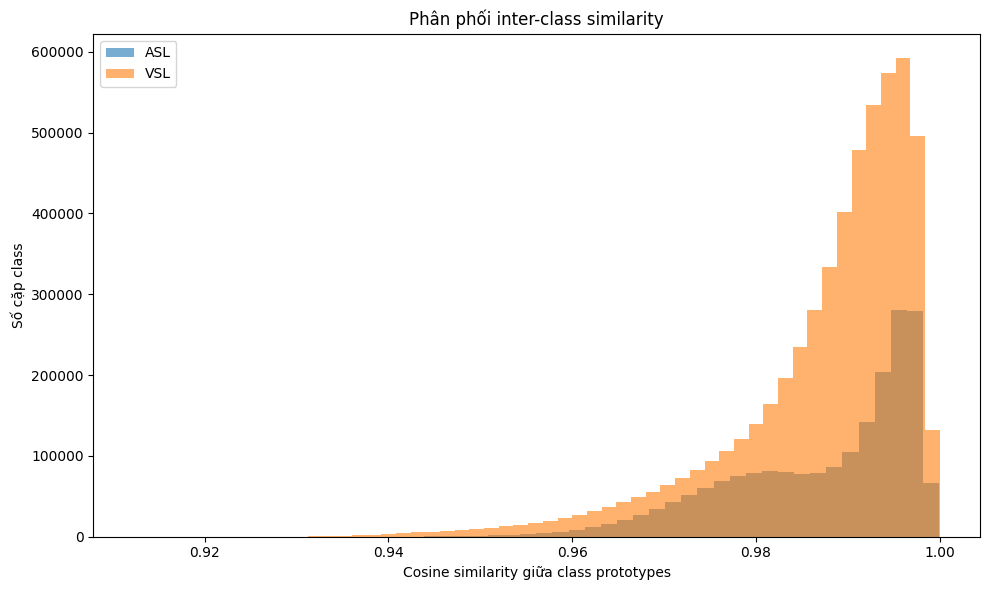

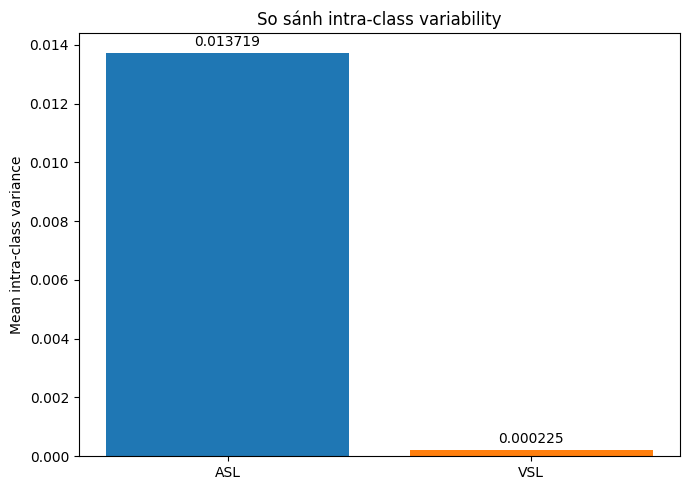

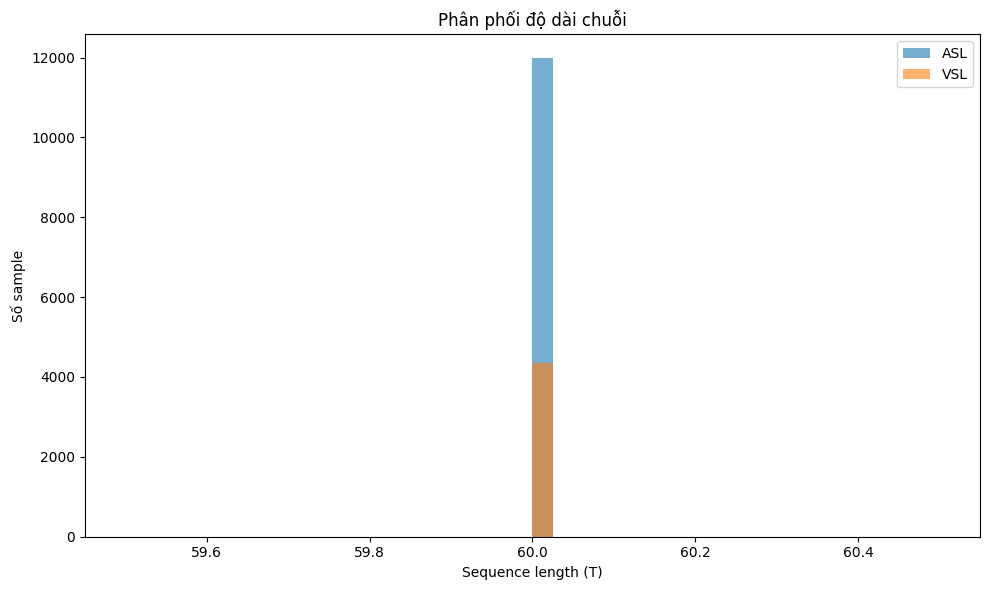

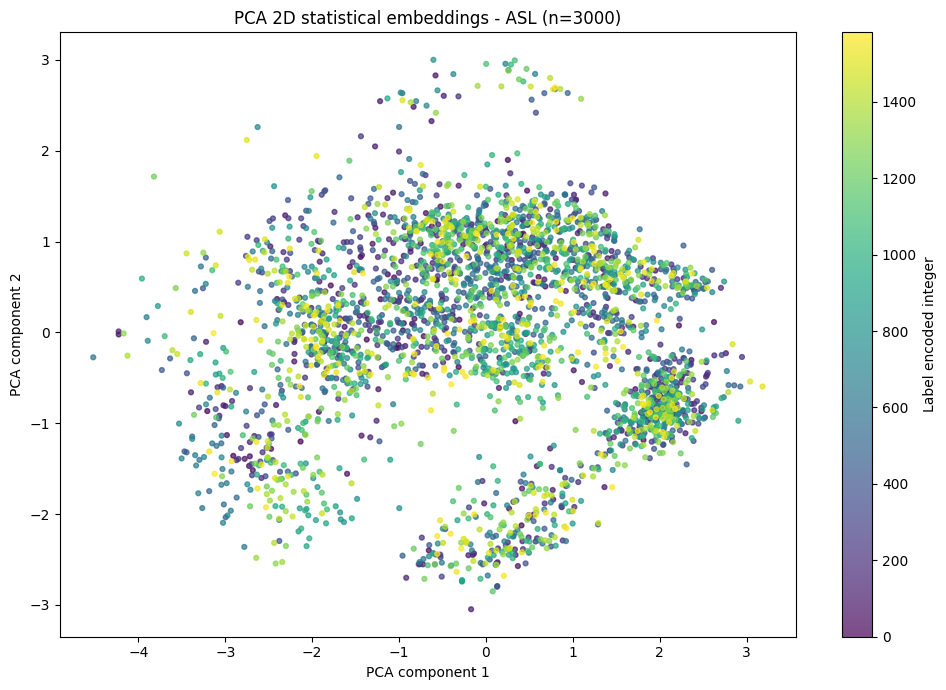

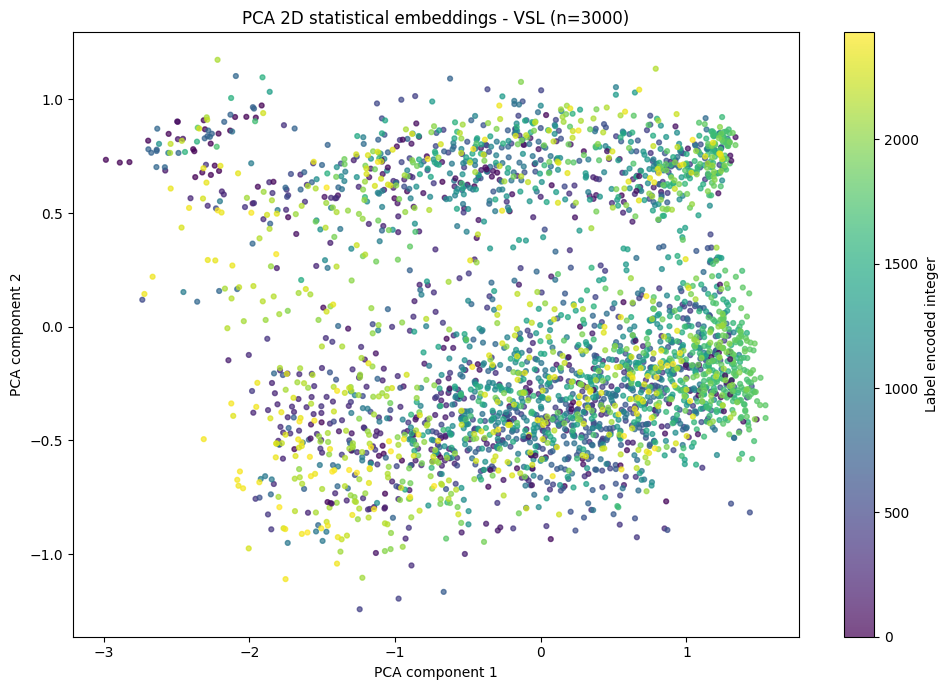


Toàn bộ đường dẫn output:
  - [đã tạo] classification_difficulty_summary.csv: /content/DBML/outputs/classification_difficulty_4_8/classification_difficulty_summary.csv
  - [đã tạo] similar_class_pairs_asl.csv: /content/DBML/outputs/classification_difficulty_4_8/similar_class_pairs_asl.csv
  - [đã tạo] similar_class_pairs_vsl.csv: /content/DBML/outputs/classification_difficulty_4_8/similar_class_pairs_vsl.csv
  - [đã tạo] intra_class_variance_asl.csv: /content/DBML/outputs/classification_difficulty_4_8/intra_class_variance_asl.csv
  - [đã tạo] intra_class_variance_vsl.csv: /content/DBML/outputs/classification_difficulty_4_8/intra_class_variance_vsl.csv
  - [đã tạo] sample_embeddings_metadata.csv: /content/DBML/outputs/classification_difficulty_4_8/sample_embeddings_metadata.csv
  - [đã tạo] error_log.csv: /content/DBML/outputs/classification_difficulty_4_8/error_log.csv
  - [đã tạo] inter_class_similarity_distribution.png: /content/DBML/outputs/classification_difficulty_4_8/inter_class

In [15]:
# Cell 15 - Vẽ và lưu biểu đồ bằng matplotlib
def save_current_figure(output_path):
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# 1. Phân phối inter-class similarity
plt.figure(figsize=(10, 6))
plt.hist(asl_pair_df["cosine_similarity"], bins=50, alpha=0.60, label="ASL")
plt.hist(vsl_pair_df["cosine_similarity"], bins=50, alpha=0.60, label="VSL")
plt.xlabel("Cosine similarity giữa class prototypes")
plt.ylabel("Số cặp class")
plt.title("Phân phối inter-class similarity")
plt.legend()
inter_hist_path = OUTPUT_DIR / "inter_class_similarity_distribution.png"
save_current_figure(inter_hist_path)

# 2. So sánh mean intra-class variance
plt.figure(figsize=(7, 5))
bar_values = [
    asl_intra_metrics["mean_intra_class_variance"],
    vsl_intra_metrics["mean_intra_class_variance"],
]
bars = plt.bar(["ASL", "VSL"], bar_values, color=["tab:blue", "tab:orange"])
plt.ylabel("Mean intra-class variance")
plt.title("So sánh intra-class variability")
plt.bar_label(bars, fmt="%.6f", padding=3)
intra_bar_path = OUTPUT_DIR / "intra_class_variance_comparison.png"
save_current_figure(intra_bar_path)

# 3. Phân phối sequence length
plt.figure(figsize=(10, 6))
plt.hist(asl_meta["sequence_length"], bins=40, alpha=0.60, label="ASL")
plt.hist(vsl_meta["sequence_length"], bins=40, alpha=0.60, label="VSL")
plt.xlabel("Sequence length (T)")
plt.ylabel("Số sample")
plt.title("Phân phối độ dài chuỗi")
plt.legend()
sequence_hist_path = OUTPUT_DIR / "sequence_length_distribution.png"
save_current_figure(sequence_hist_path)

def plot_pca_embeddings(embeddings, labels, dataset_name, output_path, max_samples=3000):
    embeddings = np.asarray(embeddings, dtype=np.float32)
    labels_array = np.asarray(labels, dtype=object)
    if embeddings.ndim != 2 or embeddings.shape[0] < 2 or embeddings.shape[1] < 2:
        print(f"Bỏ qua PCA {dataset_name}: cần ít nhất 2 sample và 2 feature.")
        return False

    rng = np.random.default_rng(42)
    sample_count = min(max_samples, embeddings.shape[0])
    if sample_count < embeddings.shape[0]:
        selected_indices = np.sort(
            rng.choice(embeddings.shape[0], size=sample_count, replace=False)
        )
    else:
        selected_indices = np.arange(embeddings.shape[0])

    sampled_embeddings = embeddings[selected_indices]
    sampled_labels = labels_array[selected_indices]
    encoded_labels = LabelEncoder().fit_transform(sampled_labels)
    pca_points = PCA(
        n_components=2, svd_solver="randomized", random_state=42
    ).fit_transform(sampled_embeddings)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        pca_points[:, 0], pca_points[:, 1],
        c=encoded_labels, cmap="viridis", s=12, alpha=0.70,
    )
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(f"PCA 2D statistical embeddings - {dataset_name} (n={sample_count})")
    colorbar = plt.colorbar(scatter)
    colorbar.set_label("Label encoded integer")
    save_current_figure(output_path)
    return True

pca_asl_path = OUTPUT_DIR / "pca_embedding_asl.png"
pca_vsl_path = OUTPUT_DIR / "pca_embedding_vsl.png"
plot_pca_embeddings(asl_embeddings, asl_labels, "ASL", pca_asl_path)
plot_pca_embeddings(vsl_embeddings, vsl_labels, "VSL", pca_vsl_path)

output_paths.update({
    inter_hist_path.name: inter_hist_path,
    intra_bar_path.name: intra_bar_path,
    sequence_hist_path.name: sequence_hist_path,
    pca_asl_path.name: pca_asl_path,
    pca_vsl_path.name: pca_vsl_path,
})
print("\nToàn bộ đường dẫn output:")
for name, path in output_paths.items():
    status = "đã tạo" if path.exists() else "chưa tạo/đã bỏ qua"
    print(f"  - [{status}] {name}: {path}")

In [16]:
# Cell 16 - In top class pairs và class có độ biến thiên cao
print("TOP 20 CẶP CLASS ASL CÓ COSINE SIMILARITY CAO NHẤT")
display(asl_pair_df.head(20))

print("TOP 20 CẶP CLASS VSL CÓ COSINE SIMILARITY CAO NHẤT")
display(vsl_pair_df.head(20))

print("TOP 20 CLASS ASL CÓ INTRA-CLASS VARIANCE CAO NHẤT")
display(asl_intra_df.head(20))

print("TOP 20 CLASS VSL CÓ INTRA-CLASS VARIANCE CAO NHẤT")
display(vsl_intra_df.head(20))

TOP 20 CẶP CLASS ASL CÓ COSINE SIMILARITY CAO NHẤT


,class_a,class_b,cosine_similarity
0,s,t,0.999918
1,t,u,0.999913
2,seven,six,0.999905
3,s,v,0.999905
4,t,v,0.999893
5,n,o,0.999881
6,u,v,0.999862
7,a,d,0.999855
8,j,o,0.999811
9,o,s,0.999797


TOP 20 CẶP CLASS VSL CÓ COSINE SIMILARITY CAO NHẤT


,class_a,class_b,cosine_similarity
0,tha,tha mồi,0.999989
1,mồ côi,mồ côi cha mẹ,0.999969
2,siêu tốc,số thập phân,0.999944
3,một cặp,một đôi,0.999941
4,bao tay (dùng cho trẻ sơ sinh),găng tay,0.999938
5,dấu huyền,dấu sắc,0.999930
6,3,4,0.999925
7,răng,siêu tốc,0.999903
8,phân số tối giản,phần trăm,0.999901
9,ngoặc kép,ngoặc đơn,0.999900


TOP 20 CLASS ASL CÓ INTRA-CLASS VARIANCE CAO NHẤT


,class_name,num_samples,mean_intra_class_variance,std_intra_class_variance
0,bus,5,0.033177,0.009339
1,nickel,4,0.032737,0.018622
2,comb,6,0.031352,0.014754
3,mad,5,0.030965,0.010961
4,blind,8,0.030596,0.012979
5,idea,8,0.029716,0.016196
6,father,7,0.029612,0.015169
7,puzzled,6,0.029479,0.007262
8,radio,6,0.029030,0.013068
9,thankful,5,0.028985,0.008172


TOP 20 CLASS VSL CÓ INTRA-CLASS VARIANCE CAO NHẤT


,class_name,num_samples,mean_intra_class_variance,std_intra_class_variance
0,sữa,3,0.007679,0.005657
1,bình thường,3,0.005887,0.003831
2,con nuôi,3,0.005755,0.003176
3,bón phân,3,0.005648,0.003720
4,đen láy (như đen nhánh),3,0.005490,0.003660
5,con ếch,3,0.005308,0.003101
6,cá kho,3,0.005075,0.002625
7,xì hơi (đánh rắm),2,0.004959,0.000118
8,bốt cảnh sát,3,0.004849,0.003146
9,vật nuôi,3,0.004849,0.003167


In [17]:
# Cell 17 - Kết luận tự động bằng tiếng Việt
asl_winning_metrics = summary_df.loc[
    summary_df["More_Difficult"] == "ASL", "Metric"
].tolist()
vsl_winning_metrics = summary_df.loc[
    summary_df["More_Difficult"] == "VSL", "Metric"
].tolist()
tie_count = int((summary_df["More_Difficult"] == "Tie").sum())

print(f"Số metric ASL khó hơn: {len(asl_winning_metrics)}")
print(f"Số metric VSL khó hơn: {len(vsl_winning_metrics)}")
print(f"Số metric bằng nhau: {tie_count}")

if len(asl_winning_metrics) > len(vsl_winning_metrics):
    harder_dataset = "ASL"
    winning_metrics = asl_winning_metrics
elif len(vsl_winning_metrics) > len(asl_winning_metrics):
    harder_dataset = "VSL"
    winning_metrics = vsl_winning_metrics
else:
    harder_dataset = None
    winning_metrics = []

if harder_dataset is not None:
    metric_text = ", ".join(winning_metrics)
    conclusion = (
        f"Dựa trên embedding thống kê được tạo từ keypoint, dataset {harder_dataset} "
        f"có xu hướng khó phân loại hơn vì có nhiều chỉ số cao hơn, bao gồm: "
        f"{metric_text}. Điều này cho thấy các lớp trong dataset này có xu hướng "
        f"gần nhau hơn trong không gian đặc trưng hoặc các sample trong cùng lớp "
        f"biến thiên mạnh hơn, làm tăng khả năng nhầm lẫn khi huấn luyện mô hình nhận diện."
    )
else:
    conclusion = (
        "Dựa trên embedding thống kê được tạo từ keypoint, hai dataset có độ khó "
        "phân loại tương đương theo số lượng chỉ số cao hơn. Cần thêm embedding từ "
        "model đã huấn luyện để đánh giá chính xác hơn."
    )

print("\nKẾT LUẬN TỰ ĐỘNG:")
print(conclusion)

Số metric ASL khó hơn: 2
Số metric VSL khó hơn: 3
Số metric bằng nhau: 2

KẾT LUẬN TỰ ĐỘNG:
Dựa trên embedding thống kê được tạo từ keypoint, dataset VSL có xu hướng khó phân loại hơn vì có nhiều chỉ số cao hơn, bao gồm: mean_inter_class_similarity, max_inter_class_similarity, number_of_similar_class_pairs_threshold_0_85. Điều này cho thấy các lớp trong dataset này có xu hướng gần nhau hơn trong không gian đặc trưng hoặc các sample trong cùng lớp biến thiên mạnh hơn, làm tăng khả năng nhầm lẫn khi huấn luyện mô hình nhận diện.


In [18]:
# Cell 18 - Đoạn giải thích có thể đưa vào paper/report
paper_paragraph = (
    "Trong phần 4.8, do chưa sử dụng embedding từ encoder đã huấn luyện, mỗi chuỗi "
    "keypoint được biểu diễn bằng embedding thống kê gồm vector trung bình và độ lệch "
    "chuẩn theo thời gian. Trên cơ sở đó, prototype của mỗi lớp được tính bằng trung "
    "bình embedding của các sample thuộc cùng lớp. Inter-class similarity được đo bằng "
    "cosine similarity giữa các prototype nhằm đánh giá mức độ gần nhau giữa các lớp "
    "khác nhau. Intra-class variability được đo bằng khoảng cách cosine giữa từng sample "
    "và prototype của lớp tương ứng nhằm đánh giá mức độ phân tán trong cùng một lớp. "
    "Dataset có inter-class similarity và intra-class variability cao hơn được xem là có "
    "độ khó phân loại lớn hơn."
)
print(paper_paragraph)

Trong phần 4.8, do chưa sử dụng embedding từ encoder đã huấn luyện, mỗi chuỗi keypoint được biểu diễn bằng embedding thống kê gồm vector trung bình và độ lệch chuẩn theo thời gian. Trên cơ sở đó, prototype của mỗi lớp được tính bằng trung bình embedding của các sample thuộc cùng lớp. Inter-class similarity được đo bằng cosine similarity giữa các prototype nhằm đánh giá mức độ gần nhau giữa các lớp khác nhau. Intra-class variability được đo bằng khoảng cách cosine giữa từng sample và prototype của lớp tương ứng nhằm đánh giá mức độ phân tán trong cùng một lớp. Dataset có inter-class similarity và intra-class variability cao hơn được xem là có độ khó phân loại lớn hơn.
